In [ ]:
# Klasifikasi Teks Berita Menggunakan Word Embedding dan Naive Bayes

Notebook ini menggabungkan tahapan pengolahan dan klasifikasi teks dari Tugas 3 dan Tugas 4.

Dataset yang digunakan terdiri dari 200 berita dengan dua kategori, yaitu Sport dan Finance.

Metode yang digunakan dalam notebook ini meliputi:

1. Preprocessing teks.
2. Skenario dengan stopwords dan tanpa stopwords.
3. Word embedding menggunakan Co-occurrence Matrix dan SVD.
4. Word embedding menggunakan Word2Vec Skip-Gram.
5. Mean Pooling untuk membentuk vektor dokumen.
6. Gaussian Naive Bayes sebagai metode klasifikasi.
7. k-Nearest Neighbors (kNN) sebagai metode klasifikasi tambahan.
8. Evaluasi menggunakan Accuracy, Precision, Recall, F1-Score, dan Confusion Matrix.
9. Perbandingan hasil dari masing-masing metode dan skenario.

In [ ]:
%pip install -q pandas numpy scikit-learn matplotlib seaborn openpyxl Sastrawi gensim

## 1. Import Library

Library yang digunakan meliputi Pandas dan NumPy untuk pengolahan data, Sastrawi untuk preprocessing bahasa Indonesia, Gensim untuk Word2Vec Skip-Gram, serta Scikit-learn untuk SVD, Naive Bayes, kNN, dan evaluasi model.

In [ ]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns

from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

from gensim.models import Word2Vec

from sklearn.model_selection import train_test_split
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Semua library berhasil diimport.")

## 2. Konfigurasi Parameter

Parameter digunakan untuk menjaga proses eksperimen tetap konsisten. Word2Vec menggunakan vector size 100, window 5, minimum count 1, dan 20 epoch. Parameter tersebut mengikuti konfigurasi Word2Vec yang telah digunakan pada Tugas 3.

Untuk metode Co-occurrence Matrix dan SVD digunakan ukuran embedding 12 dimensi dan window 2. Sedangkan kNN diuji menggunakan nilai k = 1, 3, 5, 7, dan 9.

In [ ]:
RANDOM_STATE = 42
TEST_SIZE = 0.20

# Word2Vec Skip-Gram
VECTOR_SIZE = 100
WINDOW_SIZE = 5
MIN_COUNT = 1
EPOCHS = 20

# Co-occurrence Matrix + SVD
EMBEDDING_DIM = 12
COOC_WINDOW = 2
TOP_VOCAB = 150

# kNN
K_VALUES = [1, 3, 5, 7, 9]

print("Konfigurasi berhasil dibuat.")

## 3. Memuat Dataset

Dataset berisi 200 berita yang terdiri dari dua kategori, yaitu Sport dan Finance. Dataset akan digunakan sebagai dasar untuk proses preprocessing, pembentukan representasi teks, dan klasifikasi.

In [ ]:
from google.colab import files

uploaded = files.upload()

In [ ]:
df = pd.read_excel("dataset_detik_200_berita.xlsx")

print("Ukuran dataset:", df.shape)
display(df.head())

## 4. Pemeriksaan Dataset

Pada tahap ini dilakukan pemeriksaan struktur dataset, nama kolom, jumlah data, serta distribusi kategori berita untuk memastikan dataset sesuai dengan kebutuhan klasifikasi.

In [ ]:
df = pd.read_excel("dataset_detik_200_berita.xlsx")

print("Ukuran dataset:", df.shape)
display(df.head())

## 5. Pemberian Label Numerik

Kategori berita diubah menjadi label numerik agar dapat digunakan dalam proses klasifikasi.

Finance diberi label 0 dan Sport diberi label 1.

In [ ]:
label_mapping = {
    "finance": 0,
    "sport": 1
}

df["label_num"] = df["label"].map(label_mapping)

print(df[["label", "label_num"]].head())
print("\nDistribusi label numerik:")
print(df["label_num"].value_counts())

## 6. Preprocessing Teks

Preprocessing dilakukan untuk membersihkan teks berita sebelum digunakan dalam proses word embedding.

Tahapan preprocessing meliputi:

1. Case folding.
2. Penghapusan tanda baca.
3. Tokenisasi.
4. Stopword removal.
5. Stemming menggunakan Sastrawi.

Hasil preprocessing akan digunakan untuk membentuk dua skenario, yaitu dengan stopwords dan tanpa stopwords.

## 6.1 Case Folding dan Pembersihan Teks

Case folding dilakukan dengan mengubah seluruh teks menjadi huruf kecil. Selanjutnya tanda baca dan karakter yang tidak diperlukan dihilangkan.

In [ ]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["isi_berita"].apply(clean_text)

display(df[["isi_berita", "clean_text"]].head())

## 6.2 Tokenisasi

Teks yang telah dibersihkan diubah menjadi kumpulan token atau kata.

In [ ]:
df["tokens"] = df["clean_text"].apply(lambda x: x.split())

display(df[["clean_text", "tokens"]].head())

## 6.3 Stopword Removal

Stopword removal digunakan untuk menghilangkan kata-kata umum yang dianggap kurang memberikan informasi penting dalam proses klasifikasi.

In [ ]:
stop_factory = StopWordRemoverFactory()
stopwords = set(stop_factory.get_stop_words())

def remove_stopwords(tokens):
    return [word for word in tokens if word not in stopwords]

df["tokens_without_stopwords"] = df["tokens"].apply(remove_stopwords)

display(
    df[
        ["tokens", "tokens_without_stopwords"]
    ].head()
)

## 6.4 Stemming

Stemming dilakukan menggunakan Sastrawi untuk mengubah kata menjadi bentuk dasarnya. Hasil stemming digunakan sebagai token untuk pembentukan embedding.

In [13]:
stemmer = StemmerFactory().create_stemmer()

def stemming(tokens):
    return [stemmer.stem(word) for word in tokens]

df["tokens_stemmed"] = df["tokens_without_stopwords"].apply(stemming)

display(
    df[
        ["tokens_without_stopwords", "tokens_stemmed"]
    ].head()
)

,tokens_without_stopwords,tokens_stemmed
0,"[seri, terakhir, motogp, marc, marquez, sukses...","[seri, akhir, motogp, marc, marquez, sukses, s..."
1,"[alwi, farhan, moh, zaki, ubaidillah, muhamad,...","[alwi, farhan, moh, zaki, ubaidillah, muhamad,..."
2,"[tengah, viral, insiden, cepirit, ajang, hyrox...","[tengah, viral, insiden, cepirit, ajang, hyrox..."
3,"[dejan, fedinansyah, felisha, alberta, nathani...","[dejan, fedinansyah, felisha, alberta, nathani..."
4,"[bagas, maulana, apriyani, rahayu, tak, minder...","[bagas, maulana, apriyani, rahayu, tak, minder..."


## 7. Pembagian Data Training dan Testing

Dataset dibagi menjadi data training dan data testing dengan perbandingan 80:20.

Sebanyak 160 berita digunakan sebagai data training dan 40 berita sebagai data testing. Pembagian dilakukan secara stratified agar proporsi kategori Sport dan Finance tetap seimbang pada data training maupun testing.

In [14]:
train_idx, test_idx = train_test_split(
    np.arange(len(df)),
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=df["label_num"]
)

print("Jumlah data training :", len(train_idx))
print("Jumlah data testing  :", len(test_idx))

print("\nDistribusi label training:")
print(df.loc[train_idx, "label"].value_counts())

print("\nDistribusi label testing:")
print(df.loc[test_idx, "label"].value_counts())

Jumlah data training : 160
Jumlah data testing  : 40

Distribusi label training:
label
finance    80
sport      80
Name: count, dtype: int64

Distribusi label testing:
label
finance    20
sport      20
Name: count, dtype: int64


## 8. Membentuk Dua Skenario Preprocessing

Untuk melihat pengaruh stopwords terhadap hasil klasifikasi, digunakan dua skenario preprocessing:

1. **Dengan Stopwords**, menggunakan token hasil cleaning tanpa menghilangkan stopwords.
2. **Tanpa Stopwords**, menggunakan token yang telah melalui proses stopword removal dan stemming.

In [15]:
tokens_with_sw = df["tokens"].tolist()
tokens_without_sw = df["tokens_stemmed"].tolist()

train_tokens_with_sw = [tokens_with_sw[i] for i in train_idx]
test_tokens_with_sw = [tokens_with_sw[i] for i in test_idx]

train_tokens_without_sw = [tokens_without_sw[i] for i in train_idx]
test_tokens_without_sw = [tokens_without_sw[i] for i in test_idx]

y_train = df.loc[train_idx, "label"].values
y_test = df.loc[test_idx, "label"].values

print("Dengan stopwords:")
print("Train:", len(train_tokens_with_sw))
print("Test :", len(test_tokens_with_sw))

print("\nTanpa stopwords:")
print("Train:", len(train_tokens_without_sw))
print("Test :", len(test_tokens_without_sw))

Dengan stopwords:
Train: 160
Test : 40

Tanpa stopwords:
Train: 160
Test : 40


## 9. Word Embedding dengan Word2Vec Skip-Gram

Pada bagian ini digunakan Word2Vec dengan algoritma Skip-Gram untuk membentuk representasi vektor kata.

Model dilatih hanya menggunakan data training. Parameter yang digunakan adalah vector size 100, window 5, minimum count 1, dan 20 epoch.

Parameter `sg=1` digunakan untuk memilih algoritma Skip-Gram pada Word2Vec.

In [20]:
model_skipgram_without_sw = Word2Vec(
    sentences=train_tokens_without_sw,
    vector_size=VECTOR_SIZE,
    window=WINDOW_SIZE,
    min_count=MIN_COUNT,
    sg=1,
    workers=4,
    epochs=EPOCHS,
    seed=RANDOM_STATE
)

print("Word2Vec Skip-Gram tanpa stopwords berhasil dibuat.")
print("Vocabulary :", len(model_skipgram_without_sw.wv))
print("Vector size:", model_skipgram_without_sw.vector_size)

Word2Vec Skip-Gram tanpa stopwords berhasil dibuat.
Vocabulary : 4503
Vector size: 100


In [17]:
model_skipgram_with_sw = Word2Vec(
    sentences=train_tokens_with_sw,
    vector_size=VECTOR_SIZE,
    window=WINDOW_SIZE,
    min_count=MIN_COUNT,
    sg=1,
    workers=4,
    epochs=EPOCHS,
    seed=RANDOM_STATE
)

print("Word2Vec Skip-Gram dengan stopwords berhasil dibuat.")
print("Vocabulary :", len(model_skipgram_with_sw.wv))
print("Vector size:", model_skipgram_with_sw.vector_size)

Word2Vec Skip-Gram dengan stopwords berhasil dibuat.
Vocabulary : 6460
Vector size: 100


## 10. Mean Pooling untuk Membentuk Vektor Dokumen

Setiap berita terdiri dari sejumlah token yang masing-masing memiliki vektor hasil Word2Vec.

Untuk memperoleh satu representasi vektor dari sebuah berita, digunakan Mean Pooling dengan menghitung rata-rata seluruh vektor kata yang terdapat dalam berita.

Jika suatu kata tidak terdapat dalam vocabulary Word2Vec, kata tersebut tidak digunakan dalam proses perhitungan rata-rata.

In [18]:
def document_vector(tokens, model):
    vectors = [
        model.wv[word]
        for word in tokens
        if word in model.wv
    ]

    if len(vectors) == 0:
        return np.zeros(model.vector_size)

    return np.mean(vectors, axis=0)

In [21]:
X_train_w2v_with_sw = np.array([
    document_vector(tokens, model_skipgram_with_sw)
    for tokens in train_tokens_with_sw
])

X_test_w2v_with_sw = np.array([
    document_vector(tokens, model_skipgram_with_sw)
    for tokens in test_tokens_with_sw
])

X_train_w2v_without_sw = np.array([
    document_vector(tokens, model_skipgram_without_sw)
    for tokens in train_tokens_without_sw
])

X_test_w2v_without_sw = np.array([
    document_vector(tokens, model_skipgram_without_sw)
    for tokens in test_tokens_without_sw
])

print("Dengan stopwords:")
print("X_train:", X_train_w2v_with_sw.shape)
print("X_test :", X_test_w2v_with_sw.shape)

print("\nTanpa stopwords:")
print("X_train:", X_train_w2v_without_sw.shape)
print("X_test :", X_test_w2v_without_sw.shape)

Dengan stopwords:
X_train: (160, 100)
X_test : (40, 100)

Tanpa stopwords:
X_train: (160, 100)
X_test : (40, 100)


## 11. Word Embedding dengan Co-occurrence Matrix dan SVD

Selain Word2Vec Skip-Gram, digunakan metode Co-occurrence Matrix dan Singular Value Decomposition (SVD) untuk membentuk representasi vektor kata.

Co-occurrence Matrix dibentuk berdasarkan kemunculan kata dalam konteks window tertentu. Matriks tersebut kemudian direduksi menggunakan SVD menjadi embedding dengan dimensi yang lebih kecil.

Metode ini digunakan sebagai bagian dari eksperimen Tugas 4 sehingga dapat dibandingkan dengan Word2Vec Skip-Gram.

In [22]:
def build_vocabulary(corpus, top_vocab=TOP_VOCAB):
    word_counts = {}

    for tokens in corpus:
        for word in tokens:
            word_counts[word] = word_counts.get(word, 0) + 1

    sorted_words = sorted(
        word_counts.items(),
        key=lambda x: x[1],
        reverse=True
    )

    vocabulary = [word for word, count in sorted_words[:top_vocab]]

    word_to_index = {
        word: index
        for index, word in enumerate(vocabulary)
    }

    return vocabulary, word_to_index


def build_cooccurrence_matrix(corpus, word_to_index, window_size=COOC_WINDOW):
    vocab_size = len(word_to_index)
    matrix = np.zeros(
        (vocab_size, vocab_size),
        dtype=np.float32
    )

    for tokens in corpus:
        for i, word in enumerate(tokens):
            if word not in word_to_index:
                continue

            word_index = word_to_index[word]

            start = max(0, i - window_size)
            end = min(len(tokens), i + window_size + 1)

            for j in range(start, end):
                if i == j:
                    continue

                context_word = tokens[j]

                if context_word in word_to_index:
                    context_index = word_to_index[context_word]
                    matrix[word_index, context_index] += 1

    return matrix


def create_svd_embedding(corpus, top_vocab=TOP_VOCAB):
    vocabulary, word_to_index = build_vocabulary(
        corpus,
        top_vocab=top_vocab
    )

    cooc_matrix = build_cooccurrence_matrix(
        corpus,
        word_to_index,
        window_size=COOC_WINDOW
    )

    n_components = min(
        EMBEDDING_DIM,
        max(1, cooc_matrix.shape[1] - 1)
    )

    svd = TruncatedSVD(
        n_components=n_components,
        random_state=RANDOM_STATE
    )

    word_vectors = svd.fit_transform(cooc_matrix)

    embedding = {
        word: word_vectors[index]
        for word, index in word_to_index.items()
    }

    return vocabulary, word_to_index, cooc_matrix, svd, embedding

## 11.1 Membentuk Co-occurrence Matrix dan SVD

Co-occurrence Matrix dan SVD dibentuk secara terpisah untuk masing-masing skenario preprocessing.

Model hanya menggunakan data training sehingga data testing tidak digunakan dalam proses pembentukan embedding.

In [23]:
(
    vocab_svd_with_sw,
    word_to_index_svd_with_sw,
    cooc_with_sw,
    svd_with_sw,
    embedding_svd_with_sw
) = create_svd_embedding(
    train_tokens_with_sw
)

(
    vocab_svd_without_sw,
    word_to_index_svd_without_sw,
    cooc_without_sw,
    svd_without_sw,
    embedding_svd_without_sw
) = create_svd_embedding(
    train_tokens_without_sw
)

print("SVD dengan stopwords:")
print("Vocabulary :", len(vocab_svd_with_sw))
print("Co-occurrence Matrix :", cooc_with_sw.shape)
print("Embedding :", svd_with_sw.components_.shape)

print("\nSVD tanpa stopwords:")
print("Vocabulary :", len(vocab_svd_without_sw))
print("Co-occurrence Matrix :", cooc_without_sw.shape)
print("Embedding :", svd_without_sw.components_.shape)

SVD dengan stopwords:
Vocabulary : 150
Co-occurrence Matrix : (150, 150)
Embedding : (12, 150)

SVD tanpa stopwords:
Vocabulary : 150
Co-occurrence Matrix : (150, 150)
Embedding : (12, 150)


## 12. Mean Pooling pada Embedding SVD

Embedding setiap kata diubah menjadi satu representasi vektor dokumen dengan Mean Pooling.

Untuk setiap berita, vektor kata yang terdapat dalam vocabulary SVD dirata-ratakan sehingga menghasilkan satu vektor yang mewakili keseluruhan berita.

In [24]:
def document_vector_svd(tokens, embedding, embedding_dim):
    vectors = [
        embedding[word]
        for word in tokens
        if word in embedding
    ]

    if len(vectors) == 0:
        return np.zeros(embedding_dim)

    return np.mean(vectors, axis=0)


svd_dim_with_sw = svd_with_sw.components_.shape[0]
svd_dim_without_sw = svd_without_sw.components_.shape[0]

X_train_svd_with_sw = np.array([
    document_vector_svd(
        tokens,
        embedding_svd_with_sw,
        svd_dim_with_sw
    )
    for tokens in train_tokens_with_sw
])

X_test_svd_with_sw = np.array([
    document_vector_svd(
        tokens,
        embedding_svd_with_sw,
        svd_dim_with_sw
    )
    for tokens in test_tokens_with_sw
])

X_train_svd_without_sw = np.array([
    document_vector_svd(
        tokens,
        embedding_svd_without_sw,
        svd_dim_without_sw
    )
    for tokens in train_tokens_without_sw
])

X_test_svd_without_sw = np.array([
    document_vector_svd(
        tokens,
        embedding_svd_without_sw,
        svd_dim_without_sw
    )
    for tokens in test_tokens_without_sw
])

print("SVD dengan stopwords:")
print("X_train:", X_train_svd_with_sw.shape)
print("X_test :", X_test_svd_with_sw.shape)

print("\nSVD tanpa stopwords:")
print("X_train:", X_train_svd_without_sw.shape)
print("X_test :", X_test_svd_without_sw.shape)

SVD dengan stopwords:
X_train: (160, 12)
X_test : (40, 12)

SVD tanpa stopwords:
X_train: (160, 12)
X_test : (40, 12)


## 13. Klasifikasi Menggunakan Gaussian Naive Bayes

Gaussian Naive Bayes digunakan sebagai classifier utama.

Model dilatih dan diuji pada empat representasi dokumen:

1. Word2Vec Skip-Gram dengan stopwords.
2. Word2Vec Skip-Gram tanpa stopwords.
3. Co-occurrence Matrix + SVD dengan stopwords.
4. Co-occurrence Matrix + SVD tanpa stopwords.

Penggunaan Gaussian Naive Bayes mengikuti pendekatan pada Tugas 3.

In [25]:
nb_models = {}

nb_models["Word2Vec - Dengan Stopwords"] = GaussianNB()
nb_models["Word2Vec - Tanpa Stopwords"] = GaussianNB()
nb_models["SVD - Dengan Stopwords"] = GaussianNB()
nb_models["SVD - Tanpa Stopwords"] = GaussianNB()


nb_models["Word2Vec - Dengan Stopwords"].fit(
    X_train_w2v_with_sw,
    y_train
)

nb_models["Word2Vec - Tanpa Stopwords"].fit(
    X_train_w2v_without_sw,
    y_train
)

nb_models["SVD - Dengan Stopwords"].fit(
    X_train_svd_with_sw,
    y_train
)

nb_models["SVD - Tanpa Stopwords"].fit(
    X_train_svd_without_sw,
    y_train
)

print("Seluruh model Gaussian Naive Bayes berhasil dilatih.")

Seluruh model Gaussian Naive Bayes berhasil dilatih.


In [26]:
X_test_all = {
    "Word2Vec - Dengan Stopwords": X_test_w2v_with_sw,
    "Word2Vec - Tanpa Stopwords": X_test_w2v_without_sw,
    "SVD - Dengan Stopwords": X_test_svd_with_sw,
    "SVD - Tanpa Stopwords": X_test_svd_without_sw
}

predictions_nb = {}

for name, model in nb_models.items():
    predictions_nb[name] = model.predict(X_test_all[name])

print("Prediksi Gaussian Naive Bayes selesai.")

for name, prediction in predictions_nb.items():
    print("\n", name)
    print(prediction)

Prediksi Gaussian Naive Bayes selesai.

 Word2Vec - Dengan Stopwords
['finance' 'sport' 'sport' 'sport' 'finance' 'sport' 'finance' 'sport'
 'sport' 'finance' 'sport' 'sport' 'finance' 'sport' 'finance' 'finance'
 'sport' 'finance' 'finance' 'sport' 'finance' 'sport' 'sport' 'sport'
 'sport' 'sport' 'sport' 'finance' 'sport' 'finance' 'sport' 'finance'
 'finance' 'finance' 'finance' 'finance' 'finance' 'finance' 'sport'
 'finance']

 Word2Vec - Tanpa Stopwords
['finance' 'sport' 'sport' 'sport' 'finance' 'sport' 'finance' 'sport'
 'sport' 'finance' 'sport' 'sport' 'finance' 'sport' 'finance' 'finance'
 'sport' 'finance' 'finance' 'sport' 'finance' 'sport' 'sport' 'sport'
 'sport' 'sport' 'sport' 'finance' 'sport' 'finance' 'sport' 'finance'
 'finance' 'finance' 'finance' 'finance' 'finance' 'finance' 'sport'
 'finance']

 SVD - Dengan Stopwords
['finance' 'sport' 'sport' 'sport' 'sport' 'finance' 'finance' 'finance'
 'sport' 'sport' 'sport' 'sport' 'finance' 'sport' 'finance' 'finance'

## 14. Evaluasi Gaussian Naive Bayes

Evaluasi dilakukan menggunakan:

- Accuracy
- Precision
- Recall
- F1-Score

Precision, Recall, dan F1-Score dihitung menggunakan weighted average agar mempertimbangkan jumlah data pada masing-masing kelas.

In [27]:
hasil_nb = []

for name, y_pred in predictions_nb.items():
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )
    recall = recall_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )
    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    if name.startswith("Word2Vec"):
        embedding_method = "Word2Vec Skip-Gram"
    else:
        embedding_method = "Co-occurrence + SVD"

    if "Dengan Stopwords" in name:
        scenario = "Dengan Stopwords"
    else:
        scenario = "Tanpa Stopwords"

    hasil_nb.append({
        "Embedding": embedding_method,
        "Skenario": scenario,
        "Classifier": "Gaussian Naive Bayes",
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })

hasil_nb_df = pd.DataFrame(hasil_nb)

display(
    hasil_nb_df.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-Score": "{:.4f}"
    })
)

,Embedding,Skenario,Classifier,Accuracy,Precision,Recall,F1-Score
0,Word2Vec Skip-Gram,Dengan Stopwords,Gaussian Naive Bayes,1.0000,1.0000,1.0000,1.0000
1,Word2Vec Skip-Gram,Tanpa Stopwords,Gaussian Naive Bayes,1.0000,1.0000,1.0000,1.0000
2,Co-occurrence + SVD,Dengan Stopwords,Gaussian Naive Bayes,0.7750,0.7933,0.7750,0.7714
3,Co-occurrence + SVD,Tanpa Stopwords,Gaussian Naive Bayes,0.9000,0.9167,0.9000,0.8990


## 15. Confusion Matrix Gaussian Naive Bayes

Confusion Matrix digunakan untuk melihat jumlah prediksi yang benar dan salah pada masing-masing kelas.

Label yang digunakan adalah:

- Finance
- Sport

Confusion Matrix dibuat untuk seluruh kombinasi embedding dan skenario preprocessing.

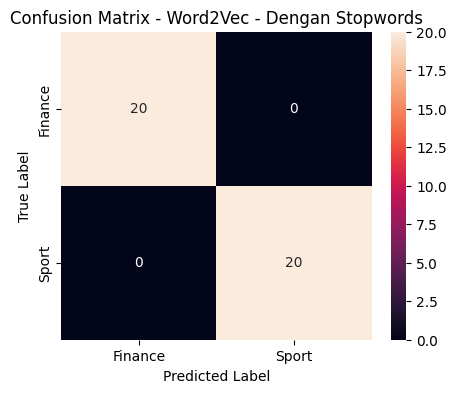

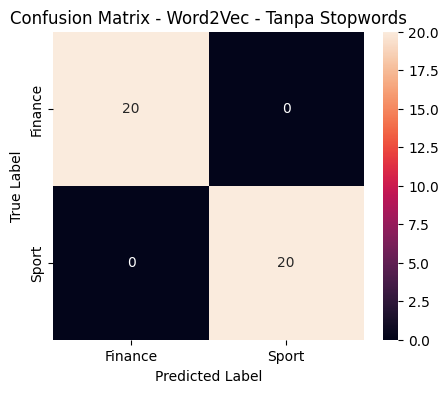

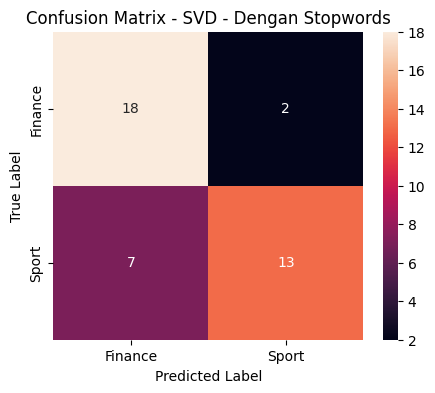

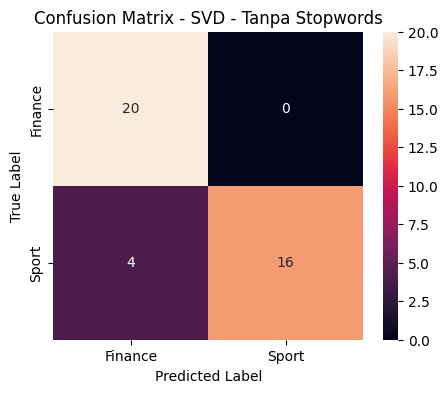

In [29]:
for name, y_pred in predictions_nb.items():
    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=["finance", "sport"]
    )

    plt.figure(figsize=(5, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=["Finance", "Sport"],
        yticklabels=["Finance", "Sport"]
    )

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

## 16. Klasifikasi Menggunakan k-Nearest Neighbors

Sebagai bagian dari eksperimen tambahan, digunakan algoritma k-Nearest Neighbors (kNN).

Nilai k yang diuji adalah:

- k = 1
- k = 3
- k = 5
- k = 7
- k = 9

Jarak yang digunakan adalah Euclidean Distance, yaitu jarak bawaan pada KNeighborsClassifier.

Pengujian dilakukan pada representasi Word2Vec Skip-Gram dan Co-occurrence + SVD untuk kedua skenario preprocessing.

In [30]:
knn_results = []

embedding_data = {
    "Word2Vec - Dengan Stopwords": (
        X_train_w2v_with_sw,
        X_test_w2v_with_sw
    ),
    "Word2Vec - Tanpa Stopwords": (
        X_train_w2v_without_sw,
        X_test_w2v_without_sw
    ),
    "SVD - Dengan Stopwords": (
        X_train_svd_with_sw,
        X_test_svd_with_sw
    ),
    "SVD - Tanpa Stopwords": (
        X_train_svd_without_sw,
        X_test_svd_without_sw
    )
}

for embedding_name, (X_train_data, X_test_data) in embedding_data.items():

    for k in K_VALUES:

        knn = KNeighborsClassifier(
            n_neighbors=k,
            metric="euclidean"
        )

        knn.fit(
            X_train_data,
            y_train
        )

        y_pred = knn.predict(X_test_data)

        accuracy = accuracy_score(
            y_test,
            y_pred
        )

        precision = precision_score(
            y_test,
            y_pred,
            average="weighted",
            zero_division=0
        )

        recall = recall_score(
            y_test,
            y_pred,
            average="weighted",
            zero_division=0
        )

        f1 = f1_score(
            y_test,
            y_pred,
            average="weighted",
            zero_division=0
        )

        if embedding_name.startswith("Word2Vec"):
            embedding_method = "Word2Vec Skip-Gram"
        else:
            embedding_method = "Co-occurrence + SVD"

        if "Dengan Stopwords" in embedding_name:
            scenario = "Dengan Stopwords"
        else:
            scenario = "Tanpa Stopwords"

        knn_results.append({
            "Embedding": embedding_method,
            "Skenario": scenario,
            "Classifier": "kNN",
            "k": k,
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1-Score": f1
        })

hasil_knn_df = pd.DataFrame(knn_results)

display(
    hasil_knn_df.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-Score": "{:.4f}"
    })
)

,Embedding,Skenario,Classifier,k,Accuracy,Precision,Recall,F1-Score
0,Word2Vec Skip-Gram,Dengan Stopwords,kNN,1,1.0000,1.0000,1.0000,1.0000
1,Word2Vec Skip-Gram,Dengan Stopwords,kNN,3,0.9750,0.9762,0.9750,0.9750
2,Word2Vec Skip-Gram,Dengan Stopwords,kNN,5,1.0000,1.0000,1.0000,1.0000
3,Word2Vec Skip-Gram,Dengan Stopwords,kNN,7,1.0000,1.0000,1.0000,1.0000
4,Word2Vec Skip-Gram,Dengan Stopwords,kNN,9,1.0000,1.0000,1.0000,1.0000
5,Word2Vec Skip-Gram,Tanpa Stopwords,kNN,1,1.0000,1.0000,1.0000,1.0000
6,Word2Vec Skip-Gram,Tanpa Stopwords,kNN,3,1.0000,1.0000,1.0000,1.0000
7,Word2Vec Skip-Gram,Tanpa Stopwords,kNN,5,1.0000,1.0000,1.0000,1.0000
8,Word2Vec Skip-Gram,Tanpa Stopwords,kNN,7,1.0000,1.0000,1.0000,1.0000
9,Word2Vec Skip-Gram,Tanpa Stopwords,kNN,9,1.0000,1.0000,1.0000,1.0000


## 17. Grafik Accuracy kNN

Accuracy setiap nilai k dibandingkan untuk melihat perubahan performa kNN pada masing-masing representasi embedding dan skenario preprocessing.

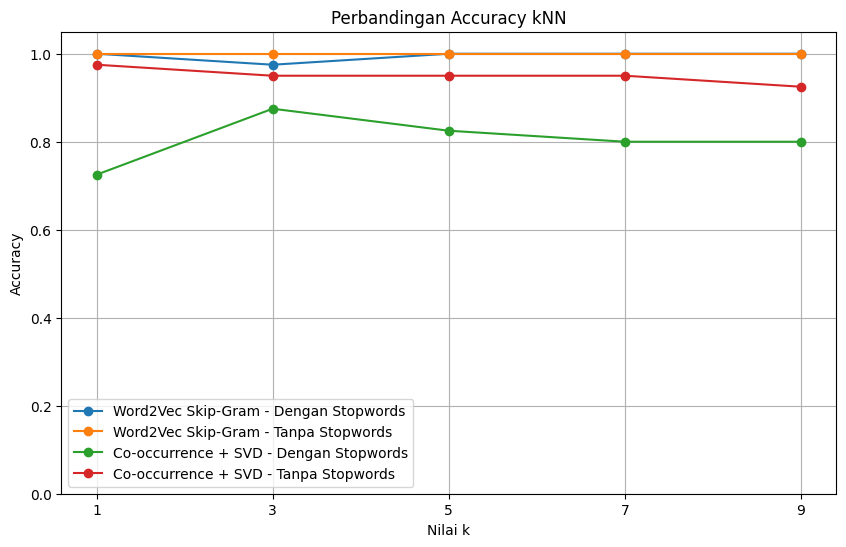

In [31]:
plt.figure(figsize=(10, 6))

for embedding_name in hasil_knn_df["Embedding"].unique():
    for scenario in hasil_knn_df["Skenario"].unique():

        subset = hasil_knn_df[
            (hasil_knn_df["Embedding"] == embedding_name) &
            (hasil_knn_df["Skenario"] == scenario)
        ]

        label = f"{embedding_name} - {scenario}"

        plt.plot(
            subset["k"],
            subset["Accuracy"],
            marker="o",
            label=label
        )

plt.xlabel("Nilai k")
plt.ylabel("Accuracy")
plt.title("Perbandingan Accuracy kNN")
plt.xticks(K_VALUES)
plt.ylim(0, 1.05)
plt.grid(True)
plt.legend()
plt.show()

## 18. Confusion Matrix kNN

Confusion Matrix ditampilkan untuk setiap kombinasi embedding, skenario preprocessing, dan nilai k.

Visualisasi ini digunakan untuk melihat pola kesalahan klasifikasi pada kelas Finance dan Sport.

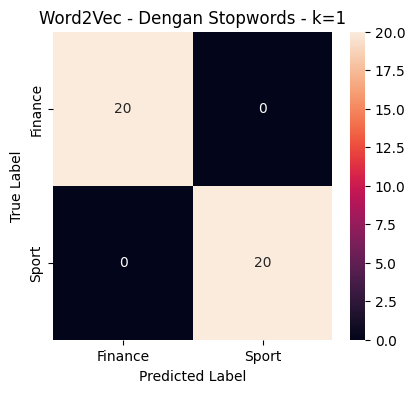

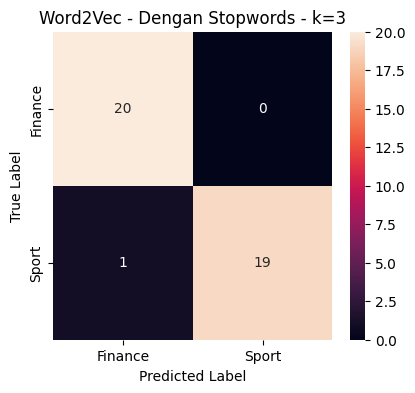

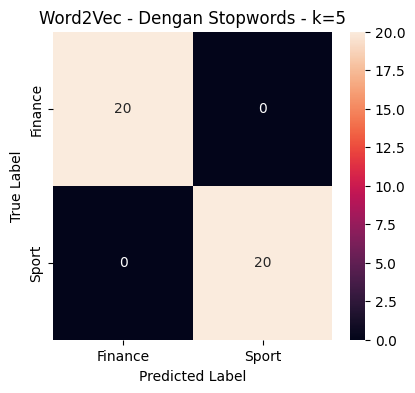

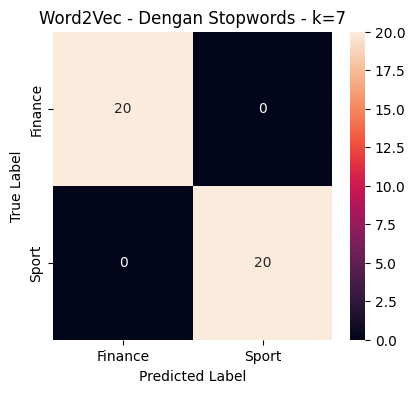

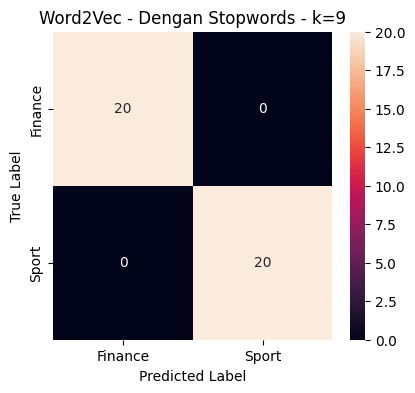

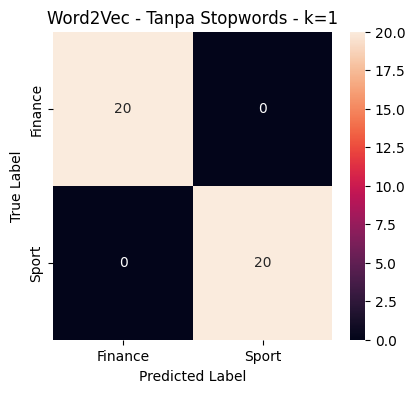

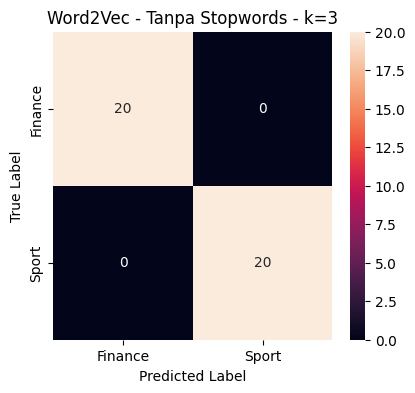

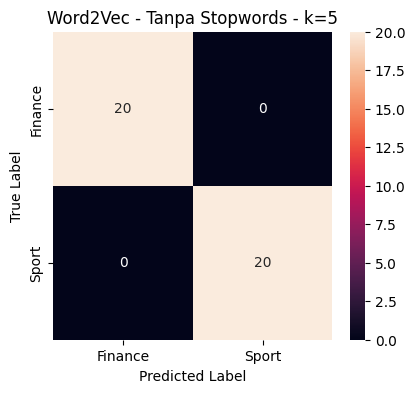

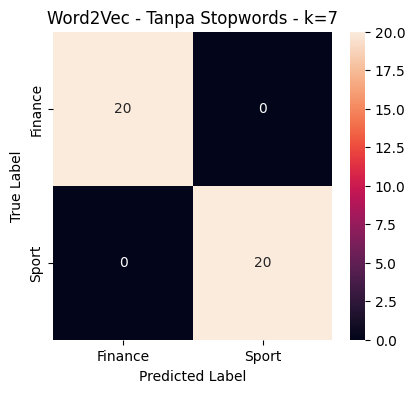

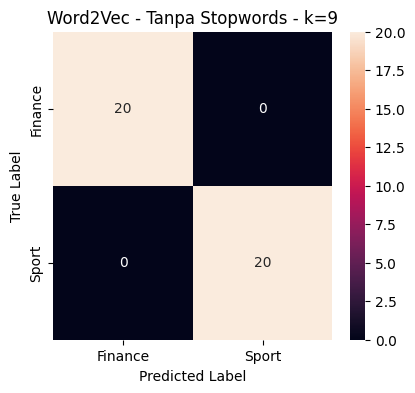

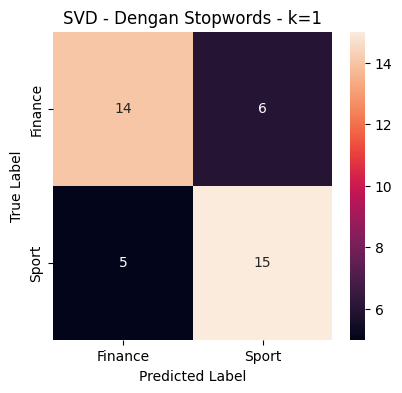

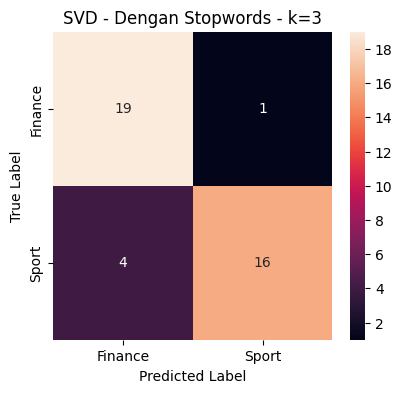

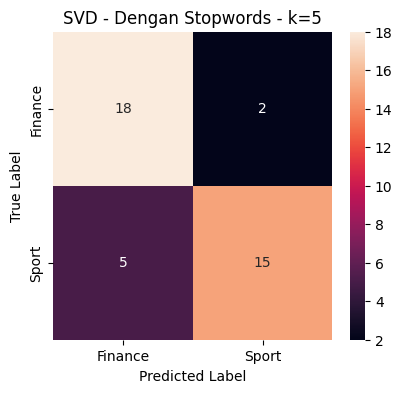

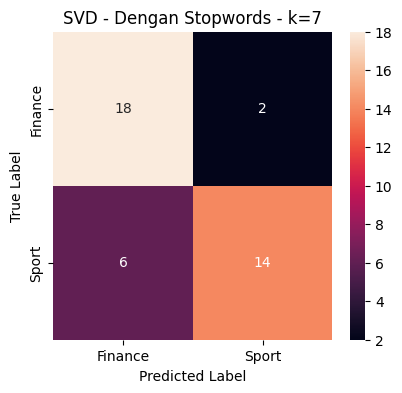

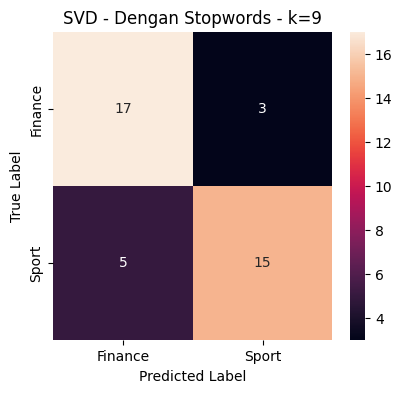

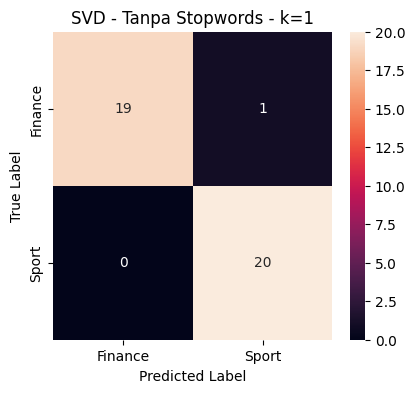

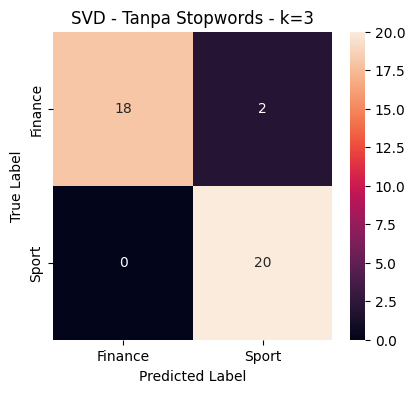

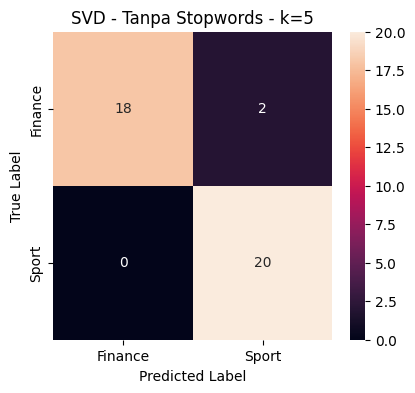

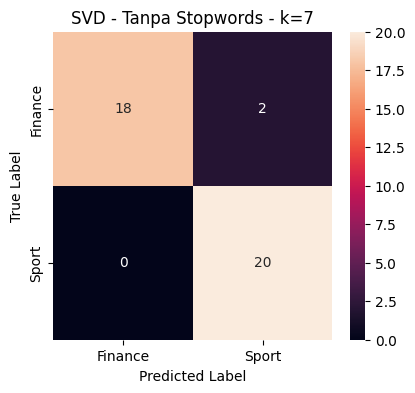

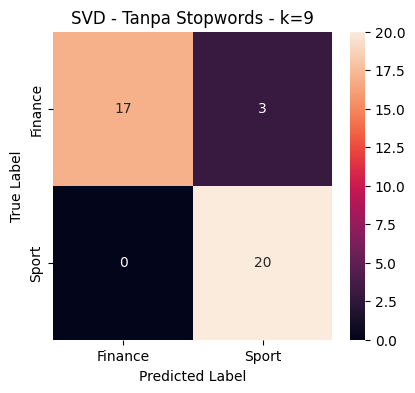

In [32]:
for embedding_name, (X_train_data, X_test_data) in embedding_data.items():

    for k in K_VALUES:

        knn = KNeighborsClassifier(
            n_neighbors=k,
            metric="euclidean"
        )

        knn.fit(
            X_train_data,
            y_train
        )

        y_pred = knn.predict(X_test_data)

        cm = confusion_matrix(
            y_test,
            y_pred,
            labels=["finance", "sport"]
        )

        plt.figure(figsize=(4.5, 4))

        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            xticklabels=["Finance", "Sport"],
            yticklabels=["Finance", "Sport"]
        )

        plt.xlabel("Predicted Label")
        plt.ylabel("True Label")
        plt.title(f"{embedding_name} - k={k}")
        plt.show()

## 19. Perbandingan Hasil Gaussian Naive Bayes dan kNN

Hasil Gaussian Naive Bayes dan kNN digabungkan ke dalam satu tabel agar performa masing-masing pendekatan dapat dibandingkan berdasarkan:

- Metode embedding
- Skenario preprocessing
- Classifier
- Nilai k
- Accuracy
- Precision
- Recall
- F1-Score

Untuk Gaussian Naive Bayes digunakan nilai k = NaN karena classifier tersebut tidak menggunakan parameter k.

In [33]:
hasil_nb_final = hasil_nb_df.copy()

hasil_nb_final["k"] = np.nan

hasil_nb_final = hasil_nb_final[
    [
        "Embedding",
        "Skenario",
        "Classifier",
        "k",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ]
]

hasil_knn_final = hasil_knn_df[
    [
        "Embedding",
        "Skenario",
        "Classifier",
        "k",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ]
].copy()

hasil_semua = pd.concat(
    [
        hasil_nb_final,
        hasil_knn_final
    ],
    ignore_index=True
)

display(
    hasil_semua.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-Score": "{:.4f}"
    })
)

,Embedding,Skenario,Classifier,k,Accuracy,Precision,Recall,F1-Score
0,Word2Vec Skip-Gram,Dengan Stopwords,Gaussian Naive Bayes,nan,1.0000,1.0000,1.0000,1.0000
1,Word2Vec Skip-Gram,Tanpa Stopwords,Gaussian Naive Bayes,nan,1.0000,1.0000,1.0000,1.0000
2,Co-occurrence + SVD,Dengan Stopwords,Gaussian Naive Bayes,nan,0.7750,0.7933,0.7750,0.7714
3,Co-occurrence + SVD,Tanpa Stopwords,Gaussian Naive Bayes,nan,0.9000,0.9167,0.9000,0.8990
4,Word2Vec Skip-Gram,Dengan Stopwords,kNN,1.000000,1.0000,1.0000,1.0000,1.0000
5,Word2Vec Skip-Gram,Dengan Stopwords,kNN,3.000000,0.9750,0.9762,0.9750,0.9750
6,Word2Vec Skip-Gram,Dengan Stopwords,kNN,5.000000,1.0000,1.0000,1.0000,1.0000
7,Word2Vec Skip-Gram,Dengan Stopwords,kNN,7.000000,1.0000,1.0000,1.0000,1.0000
8,Word2Vec Skip-Gram,Dengan Stopwords,kNN,9.000000,1.0000,1.0000,1.0000,1.0000
9,Word2Vec Skip-Gram,Tanpa Stopwords,kNN,1.000000,1.0000,1.0000,1.0000,1.0000


## 20. Visualisasi PCA

PCA digunakan sebagai visualisasi dua dimensi untuk melihat persebaran data hasil embedding.

PCA pada bagian ini hanya digunakan untuk visualisasi dan tidak digunakan sebagai classifier.

Setiap titik merepresentasikan satu berita, sedangkan warna menunjukkan kategori berita.

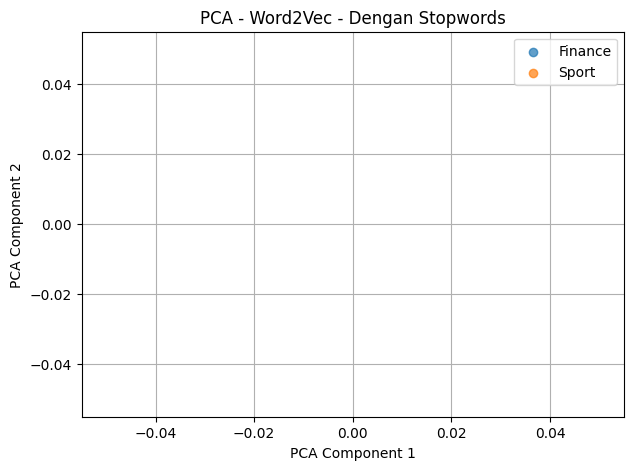

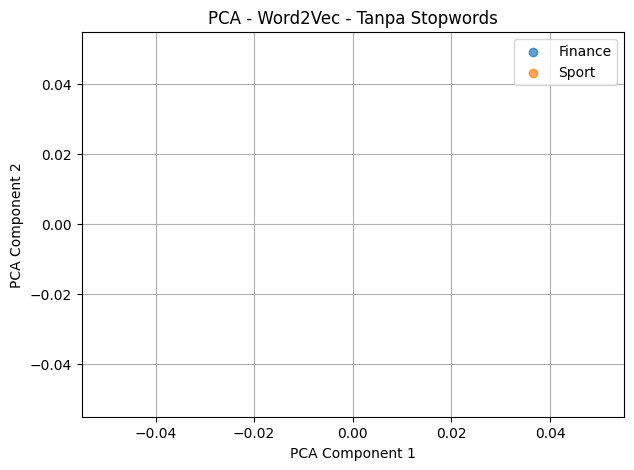

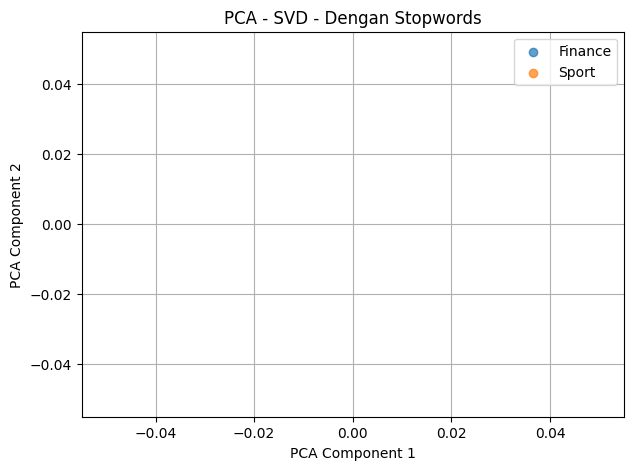

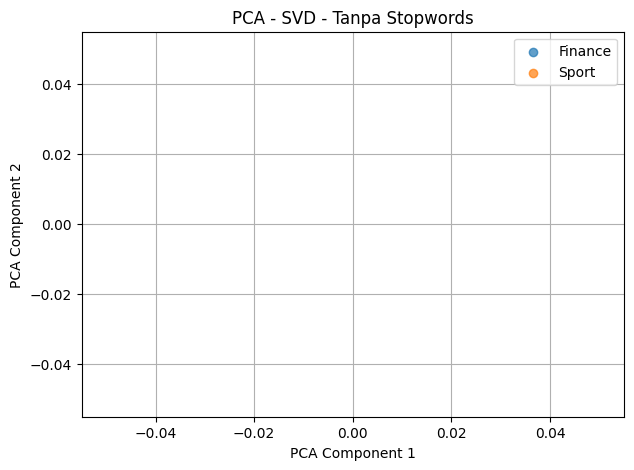

In [34]:
pca_data = {
    "Word2Vec - Dengan Stopwords": X_train_w2v_with_sw,
    "Word2Vec - Tanpa Stopwords": X_train_w2v_without_sw,
    "SVD - Dengan Stopwords": X_train_svd_with_sw,
    "SVD - Tanpa Stopwords": X_train_svd_without_sw
}

for name, X_data in pca_data.items():

    pca = PCA(
        n_components=2,
        random_state=RANDOM_STATE
    )

    X_pca = pca.fit_transform(X_data)

    plt.figure(figsize=(7, 5))

    for label, label_name in [(0, "Finance"), (1, "Sport")]:
        mask = y_train == label

        plt.scatter(
            X_pca[mask, 0],
            X_pca[mask, 1],
            label=label_name,
            alpha=0.7
        )

    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.title(f"PCA - {name}")
    plt.legend()
    plt.grid(True)
    plt.show()

## 21. Menentukan Hasil Eksperimen Berdasarkan Metrik

Tabel berikut menampilkan seluruh hasil eksperimen yang telah dilakukan.

Perbandingan dilakukan berdasarkan nilai Accuracy, Precision, Recall, dan F1-Score.

Hasil ini digunakan untuk melihat perbedaan performa berdasarkan metode embedding, skenario preprocessing, dan classifier.

In [35]:
hasil_urut = hasil_semua.sort_values(
    by=["F1-Score", "Accuracy"],
    ascending=False
).reset_index(drop=True)

display(
    hasil_urut.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-Score": "{:.4f}"
    })
)

,Embedding,Skenario,Classifier,k,Accuracy,Precision,Recall,F1-Score
0,Word2Vec Skip-Gram,Dengan Stopwords,Gaussian Naive Bayes,nan,1.0000,1.0000,1.0000,1.0000
1,Word2Vec Skip-Gram,Tanpa Stopwords,Gaussian Naive Bayes,nan,1.0000,1.0000,1.0000,1.0000
2,Word2Vec Skip-Gram,Dengan Stopwords,kNN,1.000000,1.0000,1.0000,1.0000,1.0000
3,Word2Vec Skip-Gram,Dengan Stopwords,kNN,5.000000,1.0000,1.0000,1.0000,1.0000
4,Word2Vec Skip-Gram,Dengan Stopwords,kNN,7.000000,1.0000,1.0000,1.0000,1.0000
5,Word2Vec Skip-Gram,Dengan Stopwords,kNN,9.000000,1.0000,1.0000,1.0000,1.0000
6,Word2Vec Skip-Gram,Tanpa Stopwords,kNN,1.000000,1.0000,1.0000,1.0000,1.0000
7,Word2Vec Skip-Gram,Tanpa Stopwords,kNN,3.000000,1.0000,1.0000,1.0000,1.0000
8,Word2Vec Skip-Gram,Tanpa Stopwords,kNN,5.000000,1.0000,1.0000,1.0000,1.0000
9,Word2Vec Skip-Gram,Tanpa Stopwords,kNN,7.000000,1.0000,1.0000,1.0000,1.0000


## 22. Ringkasan Hasil

Ringkasan digunakan untuk melihat nilai performa setiap eksperimen secara lebih sederhana.

Nilai metrik diperoleh langsung dari data testing sebanyak 40 berita.

In [36]:
print("Jumlah data training :", len(y_train))
print("Jumlah data testing  :", len(y_test))

print("\nDistribusi data testing:")
print(pd.Series(y_test).map({
    0: "Finance",
    1: "Sport"
}).value_counts())

print("\nJumlah eksperimen:")
print("Gaussian Naive Bayes :", len(hasil_nb_df))
print("kNN                  :", len(hasil_knn_df))
print("Total                :", len(hasil_semua))

Jumlah data training : 160
Jumlah data testing  : 40

Distribusi data testing:
Series([], Name: count, dtype: int64)

Jumlah eksperimen:
Gaussian Naive Bayes : 4
kNN                  : 20
Total                : 24


## 23. Menyimpan Hasil Eksperimen

Hasil eksperimen disimpan dalam file Excel agar dapat digunakan untuk dokumentasi tugas dan pembuatan laporan.

File berisi seluruh hasil Gaussian Naive Bayes dan kNN dari berbagai metode embedding dan skenario preprocessing.

In [37]:
hasil_semua.to_excel(
    "hasil_klasifikasi_berita.xlsx",
    index=False
)

print("File berhasil disimpan:")
print("hasil_klasifikasi_berita.xlsx")

File berhasil disimpan:
hasil_klasifikasi_berita.xlsx


In [38]:
hasil_semua.to_excel(
    "hasil_klasifikasi_berita.xlsx",
    index=False
)

print("File berhasil disimpan:")
print("hasil_klasifikasi_berita.xlsx")

File berhasil disimpan:
hasil_klasifikasi_berita.xlsx
